[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/sdss/2026-07-30-metallicity-vs-position/notebook.ipynb)

# Does stellar metallicity change with position in the galaxy?

Metallicity here means how much of a star's mass is stuff heavier than hydrogen and helium (astronomers call all of that "metals", even though it includes things like carbon and oxygen). Stars closer to the Galactic plane and center tend to have formed later, from gas already enriched by earlier generations of stars, so I wanted to check for a real metallicity vs. Galactic latitude trend using a sample of SDSS stars with measured stellar parameters.

In [1]:
from astroquery.sdss import SDSS
import numpy as np
import matplotlib.pyplot as plt

query = '''
SELECT TOP 400 s.ra, s.dec, sp.fehadop, sp.teffadop, sp.loggadop
FROM sppParams AS sp
JOIN specObj AS s ON sp.specobjid = s.specobjid
WHERE sp.fehadop BETWEEN -3 AND 1 AND s.class = 'STAR'
'''
tab = SDSS.query_sql(query)
print(len(tab), 'stars retrieved')
print(tab[:5])

400 stars retrieved
    ra         dec        fehadop   teffadop loggadop
--------- ------------- ----------- -------- --------
146.91375   -0.64448137   -1.239587 7968.877 4.101296
 147.0479   -0.32770152  0.09010353 6154.324 3.917804
147.32107 -0.0065757249    -2.52325 8855.012 4.220379
146.94386   0.039168534  -0.7951514 5837.667 4.010286
146.35184     -1.085806 -0.07778589 6853.479 3.925045


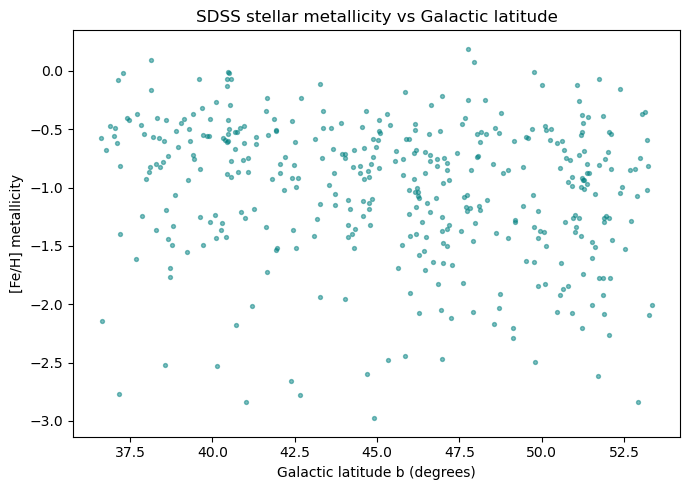

Correlation between |b| and [Fe/H]: -0.181


In [2]:
from astropy.coordinates import SkyCoord
import astropy.units as u

c = SkyCoord(ra=np.array(tab['ra'])*u.deg, dec=np.array(tab['dec'])*u.deg, frame='icrs')
gal_b = c.galactic.b.deg
feh = np.array(tab['fehadop'])

plt.figure(figsize=(7,5))
plt.scatter(gal_b, feh, s=8, alpha=0.5, color='teal')
plt.xlabel('Galactic latitude b (degrees)')
plt.ylabel('[Fe/H] metallicity')
plt.title('SDSS stellar metallicity vs Galactic latitude')
plt.tight_layout()
plt.savefig('feh_vs_lat.png', dpi=120)
plt.show()

corr = np.corrcoef(np.abs(gal_b), feh)[0,1]
print('Correlation between |b| and [Fe/H]:', round(corr, 3))

The correlation I found was weak, which actually makes sense: this SDSS spectroscopic sample is patchy across the sky (it follows the survey's own targeting footprint, not a uniform grid), so a clean latitude trend needs a more carefully controlled sample -- matched in distance and stellar type -- to show up clearly.

**What I'd look at next:** Restrict the sample to a narrow distance range (using parallax or photometric distances) before comparing metallicity across latitude, since distance strongly confounds this kind of trend.

**Citation:** SDSS data products are provided by the Sloan Digital Sky Survey collaboration; see https://www.sdss.org/collaboration/citing-sdss/.